In [1]:
print("Hello World")

Hello World


In [2]:
import requests
import pandas as pd

# URL
url = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_month.geojson"

# Fetch data
response = requests.get(url)
data = response.json()

# Extract features
rows = []

for feature in data["features"]:
    props = feature["properties"]
    coords = feature["geometry"]["coordinates"]
    
    rows.append({
        "magnitude": props["mag"],
        "place": props["place"],
        "time": props["time"],
        "updated": props["updated"],
        "tz": props["tz"],
        "url": props["url"],
        "detail": props["detail"],
        "felt": props["felt"],
        "cdi": props["cdi"],
        "mmi": props["mmi"],
        "alert": props["alert"],
        "status": props["status"],
        "tsunami": props["tsunami"],
        "sig": props["sig"],
        "net": props["net"],
        "code": props["code"],
        "ids": props["ids"],
        "sources": props["sources"],
        "types": props["types"],
        "nst": props["nst"],
        "dmin": props["dmin"],
        "rms": props["rms"],
        "gap": props["gap"],
        "magType": props["magType"],
        "type": props["type"],
        
        # Coordinates
        "longitude": coords[0],
        "latitude": coords[1],
        "depth": coords[2]
    })

# Create DataFrame
df = pd.DataFrame(rows)

# Convert timestamp (IMPORTANT)
df["time"] = pd.to_datetime(df["time"], unit="ms")
df["updated"] = pd.to_datetime(df["updated"], unit="ms")

# Save to CSV
df.to_csv("earthquake_data.csv", index=False)

print("CSV saved successfully")

CSV saved successfully


In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("earthquake_data.csv")

In [4]:
df.isnull().sum()

magnitude        7
place            0
time             0
updated          0
tz           10610
url              0
detail           0
felt         10173
cdi          10173
mmi          10337
alert        10548
status           0
tsunami          0
sig              0
net              0
code             0
ids              0
sources          0
types            0
nst              0
dmin             6
rms              0
gap              0
magType          7
type             0
longitude        0
latitude         0
depth            0
dtype: int64

In [5]:
df.head(10)

,magnitude,place,time,updated,tz,url,detail,felt,cdi,mmi,...,types,nst,dmin,rms,gap,magType,type,longitude,latitude,depth
0,1.90,"73 km WSW of Cantwell, Alaska",2026-03-20 15:48:53.612,2026-03-20 15:53:06.869,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,NaN,NaN,NaN,...,",origin,phase-data,",29,0.70000,0.70,111.0,ml,earthquake,-150.366000,63.211000,110.3000
1,2.98,"48 km W of Petrolia, CA",2026-03-20 15:43:02.360,2026-03-20 15:52:20.951,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,NaN,NaN,NaN,...,",nearby-cities,origin,phase-data,scitech-link,",51,0.39500,0.19,238.0,md,earthquake,-124.855164,40.337502,11.0000
2,4.60,"52 km WNW of La Ligua, Chile",2026-03-20 15:30:45.163,2026-03-20 15:44:02.040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,NaN,NaN,NaN,...,",origin,phase-data,",28,0.63300,0.39,107.0,mb,earthquake,-71.698700,-32.196700,57.4620
3,2.26,"14 km SE of Pāhala, Hawaii",2026-03-20 15:25:30.480,2026-03-20 15:29:58.940,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,NaN,NaN,NaN,...,",origin,phase-data,",45,0.09015,0.14,187.0,ml,earthquake,-155.371674,19.126667,28.5000
4,1.80,"115 km N of Yakutat, Alaska",2026-03-20 15:16:08.872,2026-03-20 15:19:38.199,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,NaN,NaN,NaN,...,",origin,phase-data,",13,0.50000,0.80,119.0,ml,earthquake,-139.962000,60.578000,0.3000
5,0.78,"4 km W of Lake Henshaw, CA",2026-03-20 15:01:56.400,2026-03-20 15:05:29.697,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,NaN,NaN,NaN,...,",nearby-cities,origin,phase-data,scitech-link,",28,0.04122,0.11,40.0,ml,earthquake,-116.806667,33.245333,12.9400
6,2.90,"27 km SSW of Nikolski, Alaska",2026-03-20 14:51:47.263,2026-03-20 14:56:03.370,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,NaN,NaN,NaN,...,",origin,phase-data,",15,0.30000,0.80,323.0,ml,earthquake,-168.972000,52.701000,9.8000
7,1.70,"20 km ESE of Kasilof, Alaska",2026-03-20 14:51:43.580,2026-03-20 14:56:54.843,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,NaN,NaN,NaN,...,",origin,phase-data,",25,0.50000,0.40,68.0,ml,earthquake,-150.965000,60.242000,60.9000
8,2.00,"14 km SSW of Mentone, Texas",2026-03-20 14:50:01.605,2026-03-20 15:01:35.875,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,NaN,NaN,NaN,...,",origin,phase-data,",15,0.00000,0.80,83.0,ml,earthquake,-103.678000,31.589000,19.4551
9,2.60,"13 km W of Stanton, Texas",2026-03-20 14:49:36.775,2026-03-20 15:33:05.793,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,0.0,1.0,NaN,...,",dyfi,origin,phase-data,",34,0.10000,0.10,58.0,ml,earthquake,-101.931000,32.108000,8.9111


In [6]:
drop_cols = ["ids", "sources", "types", "url", "detail"]
df = df.drop(columns=drop_cols, errors="ignore")

In [12]:
df.head(10)

,magnitude,place,time,updated,tz,felt,cdi,mmi,alert,status,...,code,nst,dmin,rms,gap,magType,type,longitude,latitude,depth
0,1.90,"73 km WSW of Cantwell, Alaska",2026-03-20 15:48:53.612,2026-03-20 15:53:06.869,NaN,NaN,NaN,NaN,NaN,automatic,...,a2026fokcqm,29,0.70000,0.70,111.0,ml,earthquake,-150.366000,63.211000,110.3000
1,2.98,"48 km W of Petrolia, CA",2026-03-20 15:43:02.360,2026-03-20 15:52:20.951,NaN,NaN,NaN,NaN,NaN,automatic,...,75330657,51,0.39500,0.19,238.0,md,earthquake,-124.855164,40.337502,11.0000
2,4.60,"52 km WNW of La Ligua, Chile",2026-03-20 15:30:45.163,2026-03-20 15:44:02.040,NaN,NaN,NaN,NaN,NaN,reviewed,...,6000shvi,28,0.63300,0.39,107.0,mb,earthquake,-71.698700,-32.196700,57.4620
3,2.26,"14 km SE of Pāhala, Hawaii",2026-03-20 15:25:30.480,2026-03-20 15:29:58.940,NaN,NaN,NaN,NaN,NaN,automatic,...,74920052,45,0.09015,0.14,187.0,ml,earthquake,-155.371674,19.126667,28.5000
4,1.80,"115 km N of Yakutat, Alaska",2026-03-20 15:16:08.872,2026-03-20 15:19:38.199,NaN,NaN,NaN,NaN,NaN,automatic,...,a2026fojady,13,0.50000,0.80,119.0,ml,earthquake,-139.962000,60.578000,0.3000
5,0.78,"4 km W of Lake Henshaw, CA",2026-03-20 15:01:56.400,2026-03-20 15:05:29.697,NaN,NaN,NaN,NaN,NaN,automatic,...,41420872,28,0.04122,0.11,40.0,ml,earthquake,-116.806667,33.245333,12.9400
6,2.90,"27 km SSW of Nikolski, Alaska",2026-03-20 14:51:47.263,2026-03-20 14:56:03.370,NaN,NaN,NaN,NaN,NaN,automatic,...,a2026foifdb,15,0.30000,0.80,323.0,ml,earthquake,-168.972000,52.701000,9.8000
7,1.70,"20 km ESE of Kasilof, Alaska",2026-03-20 14:51:43.580,2026-03-20 14:56:54.843,NaN,NaN,NaN,NaN,NaN,automatic,...,a2026foifcr,25,0.50000,0.40,68.0,ml,earthquake,-150.965000,60.242000,60.9000
8,2.00,"14 km SSW of Mentone, Texas",2026-03-20 14:50:01.605,2026-03-20 15:01:35.875,NaN,NaN,NaN,NaN,NaN,automatic,...,2026foidqn,15,0.00000,0.80,83.0,ml,earthquake,-103.678000,31.589000,19.4551
9,2.60,"13 km W of Stanton, Texas",2026-03-20 14:49:36.775,2026-03-20 15:33:05.793,NaN,0.0,1.0,NaN,NaN,reviewed,...,2026foidgi,34,0.10000,0.10,58.0,ml,earthquake,-101.931000,32.108000,8.9111


In [7]:
df.drop(columns=["code", "ids", "sources", "types"], inplace=True, errors="ignore")

In [14]:
df.head(10)

,magnitude,place,time,updated,tz,felt,cdi,mmi,alert,status,...,net,nst,dmin,rms,gap,magType,type,longitude,latitude,depth
0,1.90,"73 km WSW of Cantwell, Alaska",2026-03-20 15:48:53.612,2026-03-20 15:53:06.869,NaN,NaN,NaN,NaN,NaN,automatic,...,ak,29,0.70000,0.70,111.0,ml,earthquake,-150.366000,63.211000,110.3000
1,2.98,"48 km W of Petrolia, CA",2026-03-20 15:43:02.360,2026-03-20 15:52:20.951,NaN,NaN,NaN,NaN,NaN,automatic,...,nc,51,0.39500,0.19,238.0,md,earthquake,-124.855164,40.337502,11.0000
2,4.60,"52 km WNW of La Ligua, Chile",2026-03-20 15:30:45.163,2026-03-20 15:44:02.040,NaN,NaN,NaN,NaN,NaN,reviewed,...,us,28,0.63300,0.39,107.0,mb,earthquake,-71.698700,-32.196700,57.4620
3,2.26,"14 km SE of Pāhala, Hawaii",2026-03-20 15:25:30.480,2026-03-20 15:29:58.940,NaN,NaN,NaN,NaN,NaN,automatic,...,hv,45,0.09015,0.14,187.0,ml,earthquake,-155.371674,19.126667,28.5000
4,1.80,"115 km N of Yakutat, Alaska",2026-03-20 15:16:08.872,2026-03-20 15:19:38.199,NaN,NaN,NaN,NaN,NaN,automatic,...,ak,13,0.50000,0.80,119.0,ml,earthquake,-139.962000,60.578000,0.3000
5,0.78,"4 km W of Lake Henshaw, CA",2026-03-20 15:01:56.400,2026-03-20 15:05:29.697,NaN,NaN,NaN,NaN,NaN,automatic,...,ci,28,0.04122,0.11,40.0,ml,earthquake,-116.806667,33.245333,12.9400
6,2.90,"27 km SSW of Nikolski, Alaska",2026-03-20 14:51:47.263,2026-03-20 14:56:03.370,NaN,NaN,NaN,NaN,NaN,automatic,...,ak,15,0.30000,0.80,323.0,ml,earthquake,-168.972000,52.701000,9.8000
7,1.70,"20 km ESE of Kasilof, Alaska",2026-03-20 14:51:43.580,2026-03-20 14:56:54.843,NaN,NaN,NaN,NaN,NaN,automatic,...,ak,25,0.50000,0.40,68.0,ml,earthquake,-150.965000,60.242000,60.9000
8,2.00,"14 km SSW of Mentone, Texas",2026-03-20 14:50:01.605,2026-03-20 15:01:35.875,NaN,NaN,NaN,NaN,NaN,automatic,...,tx,15,0.00000,0.80,83.0,ml,earthquake,-103.678000,31.589000,19.4551
9,2.60,"13 km W of Stanton, Texas",2026-03-20 14:49:36.775,2026-03-20 15:33:05.793,NaN,0.0,1.0,NaN,NaN,reviewed,...,tx,34,0.10000,0.10,58.0,ml,earthquake,-101.931000,32.108000,8.9111


In [8]:
#handling missing values 

df = df.dropna(subset=["magnitude"])
df = df.drop(columns=["tz"], errors="ignore")

df["felt"] = df["felt"].fillna(0)
df["cdi"] = df["cdi"].fillna(df["cdi"].median())
df["mmi"] = df["mmi"].fillna(df["mmi"].median())
df["alert"] = df["alert"].fillna("unknown")

In [16]:
df.head(10)

,magnitude,place,time,updated,felt,cdi,mmi,alert,status,tsunami,...,net,nst,dmin,rms,gap,magType,type,longitude,latitude,depth
0,1.90,"73 km WSW of Cantwell, Alaska",2026-03-20 15:48:53.612,2026-03-20 15:53:06.869,0.0,2.2,2.67,unknown,automatic,0,...,ak,29,0.70000,0.70,111.0,ml,earthquake,-150.366000,63.211000,110.3000
1,2.98,"48 km W of Petrolia, CA",2026-03-20 15:43:02.360,2026-03-20 15:52:20.951,0.0,2.2,2.67,unknown,automatic,0,...,nc,51,0.39500,0.19,238.0,md,earthquake,-124.855164,40.337502,11.0000
2,4.60,"52 km WNW of La Ligua, Chile",2026-03-20 15:30:45.163,2026-03-20 15:44:02.040,0.0,2.2,2.67,unknown,reviewed,0,...,us,28,0.63300,0.39,107.0,mb,earthquake,-71.698700,-32.196700,57.4620
3,2.26,"14 km SE of Pāhala, Hawaii",2026-03-20 15:25:30.480,2026-03-20 15:29:58.940,0.0,2.2,2.67,unknown,automatic,0,...,hv,45,0.09015,0.14,187.0,ml,earthquake,-155.371674,19.126667,28.5000
4,1.80,"115 km N of Yakutat, Alaska",2026-03-20 15:16:08.872,2026-03-20 15:19:38.199,0.0,2.2,2.67,unknown,automatic,0,...,ak,13,0.50000,0.80,119.0,ml,earthquake,-139.962000,60.578000,0.3000
5,0.78,"4 km W of Lake Henshaw, CA",2026-03-20 15:01:56.400,2026-03-20 15:05:29.697,0.0,2.2,2.67,unknown,automatic,0,...,ci,28,0.04122,0.11,40.0,ml,earthquake,-116.806667,33.245333,12.9400
6,2.90,"27 km SSW of Nikolski, Alaska",2026-03-20 14:51:47.263,2026-03-20 14:56:03.370,0.0,2.2,2.67,unknown,automatic,0,...,ak,15,0.30000,0.80,323.0,ml,earthquake,-168.972000,52.701000,9.8000
7,1.70,"20 km ESE of Kasilof, Alaska",2026-03-20 14:51:43.580,2026-03-20 14:56:54.843,0.0,2.2,2.67,unknown,automatic,0,...,ak,25,0.50000,0.40,68.0,ml,earthquake,-150.965000,60.242000,60.9000
8,2.00,"14 km SSW of Mentone, Texas",2026-03-20 14:50:01.605,2026-03-20 15:01:35.875,0.0,2.2,2.67,unknown,automatic,0,...,tx,15,0.00000,0.80,83.0,ml,earthquake,-103.678000,31.589000,19.4551
9,2.60,"13 km W of Stanton, Texas",2026-03-20 14:49:36.775,2026-03-20 15:33:05.793,0.0,1.0,2.67,unknown,reviewed,0,...,tx,34,0.10000,0.10,58.0,ml,earthquake,-101.931000,32.108000,8.9111


In [9]:
df["time"] = pd.to_datetime(df["time"])
df["updated"] = pd.to_datetime(df["updated"])

In [18]:
df.head(10)

,magnitude,place,time,updated,felt,cdi,mmi,alert,status,tsunami,...,net,nst,dmin,rms,gap,magType,type,longitude,latitude,depth
0,1.90,"73 km WSW of Cantwell, Alaska",2026-03-20 15:48:53.612,2026-03-20 15:53:06.869,0.0,2.2,2.67,unknown,automatic,0,...,ak,29,0.70000,0.70,111.0,ml,earthquake,-150.366000,63.211000,110.3000
1,2.98,"48 km W of Petrolia, CA",2026-03-20 15:43:02.360,2026-03-20 15:52:20.951,0.0,2.2,2.67,unknown,automatic,0,...,nc,51,0.39500,0.19,238.0,md,earthquake,-124.855164,40.337502,11.0000
2,4.60,"52 km WNW of La Ligua, Chile",2026-03-20 15:30:45.163,2026-03-20 15:44:02.040,0.0,2.2,2.67,unknown,reviewed,0,...,us,28,0.63300,0.39,107.0,mb,earthquake,-71.698700,-32.196700,57.4620
3,2.26,"14 km SE of Pāhala, Hawaii",2026-03-20 15:25:30.480,2026-03-20 15:29:58.940,0.0,2.2,2.67,unknown,automatic,0,...,hv,45,0.09015,0.14,187.0,ml,earthquake,-155.371674,19.126667,28.5000
4,1.80,"115 km N of Yakutat, Alaska",2026-03-20 15:16:08.872,2026-03-20 15:19:38.199,0.0,2.2,2.67,unknown,automatic,0,...,ak,13,0.50000,0.80,119.0,ml,earthquake,-139.962000,60.578000,0.3000
5,0.78,"4 km W of Lake Henshaw, CA",2026-03-20 15:01:56.400,2026-03-20 15:05:29.697,0.0,2.2,2.67,unknown,automatic,0,...,ci,28,0.04122,0.11,40.0,ml,earthquake,-116.806667,33.245333,12.9400
6,2.90,"27 km SSW of Nikolski, Alaska",2026-03-20 14:51:47.263,2026-03-20 14:56:03.370,0.0,2.2,2.67,unknown,automatic,0,...,ak,15,0.30000,0.80,323.0,ml,earthquake,-168.972000,52.701000,9.8000
7,1.70,"20 km ESE of Kasilof, Alaska",2026-03-20 14:51:43.580,2026-03-20 14:56:54.843,0.0,2.2,2.67,unknown,automatic,0,...,ak,25,0.50000,0.40,68.0,ml,earthquake,-150.965000,60.242000,60.9000
8,2.00,"14 km SSW of Mentone, Texas",2026-03-20 14:50:01.605,2026-03-20 15:01:35.875,0.0,2.2,2.67,unknown,automatic,0,...,tx,15,0.00000,0.80,83.0,ml,earthquake,-103.678000,31.589000,19.4551
9,2.60,"13 km W of Stanton, Texas",2026-03-20 14:49:36.775,2026-03-20 15:33:05.793,0.0,1.0,2.67,unknown,reviewed,0,...,tx,34,0.10000,0.10,58.0,ml,earthquake,-101.931000,32.108000,8.9111


In [10]:
df["location"] = df["place"].apply(lambda x: x.split("of")[-1].strip() if "of" in x else x)

In [20]:
df.head(10)

,magnitude,place,time,updated,felt,cdi,mmi,alert,status,tsunami,...,nst,dmin,rms,gap,magType,type,longitude,latitude,depth,location
0,1.90,"73 km WSW of Cantwell, Alaska",2026-03-20 15:48:53.612,2026-03-20 15:53:06.869,0.0,2.2,2.67,unknown,automatic,0,...,29,0.70000,0.70,111.0,ml,earthquake,-150.366000,63.211000,110.3000,"Cantwell, Alaska"
1,2.98,"48 km W of Petrolia, CA",2026-03-20 15:43:02.360,2026-03-20 15:52:20.951,0.0,2.2,2.67,unknown,automatic,0,...,51,0.39500,0.19,238.0,md,earthquake,-124.855164,40.337502,11.0000,"Petrolia, CA"
2,4.60,"52 km WNW of La Ligua, Chile",2026-03-20 15:30:45.163,2026-03-20 15:44:02.040,0.0,2.2,2.67,unknown,reviewed,0,...,28,0.63300,0.39,107.0,mb,earthquake,-71.698700,-32.196700,57.4620,"La Ligua, Chile"
3,2.26,"14 km SE of Pāhala, Hawaii",2026-03-20 15:25:30.480,2026-03-20 15:29:58.940,0.0,2.2,2.67,unknown,automatic,0,...,45,0.09015,0.14,187.0,ml,earthquake,-155.371674,19.126667,28.5000,"Pāhala, Hawaii"
4,1.80,"115 km N of Yakutat, Alaska",2026-03-20 15:16:08.872,2026-03-20 15:19:38.199,0.0,2.2,2.67,unknown,automatic,0,...,13,0.50000,0.80,119.0,ml,earthquake,-139.962000,60.578000,0.3000,"Yakutat, Alaska"
5,0.78,"4 km W of Lake Henshaw, CA",2026-03-20 15:01:56.400,2026-03-20 15:05:29.697,0.0,2.2,2.67,unknown,automatic,0,...,28,0.04122,0.11,40.0,ml,earthquake,-116.806667,33.245333,12.9400,"Lake Henshaw, CA"
6,2.90,"27 km SSW of Nikolski, Alaska",2026-03-20 14:51:47.263,2026-03-20 14:56:03.370,0.0,2.2,2.67,unknown,automatic,0,...,15,0.30000,0.80,323.0,ml,earthquake,-168.972000,52.701000,9.8000,"Nikolski, Alaska"
7,1.70,"20 km ESE of Kasilof, Alaska",2026-03-20 14:51:43.580,2026-03-20 14:56:54.843,0.0,2.2,2.67,unknown,automatic,0,...,25,0.50000,0.40,68.0,ml,earthquake,-150.965000,60.242000,60.9000,", Alaska"
8,2.00,"14 km SSW of Mentone, Texas",2026-03-20 14:50:01.605,2026-03-20 15:01:35.875,0.0,2.2,2.67,unknown,automatic,0,...,15,0.00000,0.80,83.0,ml,earthquake,-103.678000,31.589000,19.4551,"Mentone, Texas"
9,2.60,"13 km W of Stanton, Texas",2026-03-20 14:49:36.775,2026-03-20 15:33:05.793,0.0,1.0,2.67,unknown,reviewed,0,...,34,0.10000,0.10,58.0,ml,earthquake,-101.931000,32.108000,8.9111,"Stanton, Texas"


In [21]:
df.isnull().sum()

magnitude    0
place        0
time         0
updated      0
felt         0
cdi          0
mmi          0
alert        0
status       0
tsunami      0
sig          0
net          0
nst          0
dmin         6
rms          0
gap          0
magType      0
type         0
longitude    0
latitude     0
depth        0
location     0
dtype: int64

In [22]:
df.describe()

,magnitude,time,updated,felt,cdi,mmi,tsunami,sig,nst,dmin,rms,gap,longitude,latitude,depth
count,10603.000000,10603,10603,10603.000000,10603.000000,10603.000000,10603.000000,10603.000000,10603.000000,10597.000000,10603.000000,10603.000000,10603.000000,10603.000000,10603.000000
mean,1.729870,2026-03-05 08:06:43.108439,2026-03-08 16:43:09.590780,1.328869,2.205074,2.675948,0.001132,68.391116,26.828162,0.471768,0.325090,110.630440,-110.528635,40.483281,22.203102
min,-1.250000,2026-02-18 15:57:53.659000,2026-02-18 16:22:53.970000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.000000,-179.980800,-84.493200,-3.170000
25%,0.930000,2026-02-26 01:53:35.825000,2026-03-02 23:56:16.525000,0.000000,2.200000,2.670000,0.000000,13.000000,12.000000,0.023710,0.100000,62.000000,-149.957500,33.459417,3.700000
50%,1.600000,2026-03-05 02:16:17.123000,2026-03-09 16:32:54.914000,0.000000,2.200000,2.670000,0.000000,39.000000,20.000000,0.100000,0.200000,87.000000,-122.624168,38.796000,7.894300
75%,2.200000,2026-03-12 11:53:47.317500,2026-03-16 09:21:36.191500,0.000000,2.200000,2.670000,0.000000,74.000000,33.000000,0.400000,0.540000,146.000000,-112.017083,53.859650,15.000000
max,7.000000,2026-03-20 15:48:53.612000,2026-03-20 15:53:06.869000,2491.000000,6.000000,6.975000,1.000000,889.000000,300.000000,46.843000,1.880000,356.000000,179.998900,83.755200,750.000000
std,1.198671,NaN,NaN,39.205617,0.281406,0.207255,0.033624,92.110268,23.865649,1.579648,0.299451,67.613712,71.107217,17.386424,55.165916


In [24]:
df.info()

<class 'pandas.DataFrame'>
Index: 10603 entries, 0 to 10609
Data columns (total 22 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   magnitude  10603 non-null  float64       
 1   place      10603 non-null  str           
 2   time       10603 non-null  datetime64[us]
 3   updated    10603 non-null  datetime64[us]
 4   felt       10603 non-null  float64       
 5   cdi        10603 non-null  float64       
 6   mmi        10603 non-null  float64       
 7   alert      10603 non-null  str           
 8   status     10603 non-null  str           
 9   tsunami    10603 non-null  int64         
 10  sig        10603 non-null  int64         
 11  net        10603 non-null  str           
 12  nst        10603 non-null  int64         
 13  dmin       10597 non-null  float64       
 14  rms        10603 non-null  float64       
 15  gap        10603 non-null  float64       
 16  magType    10603 non-null  str           
 17  type     

In [25]:
#feature Enginneriing


df["hour"] = df["time"].dt.hour
df["day"] = df["time"].dt.day
df["month"] = df["time"].dt.month
df["weekday"] = df["time"].dt.weekday

In [26]:
df["depth_category"] = pd.cut(df["depth"],bins=[-1, 70, 300, 700],labels=["shallow", "intermediate", "deep"])

In [27]:
df["country"] = df["location"].apply(lambda x: x.split(",")[-1].strip() if "," in x else x)

In [28]:
df["depth_mag_interaction"] = df["depth"] * df["magnitude"]
df["lat_lon_interaction"] = df["latitude"] * df["longitude"]

In [29]:
df["distance_from_center"] = np.sqrt(df["latitude"]**2 + df["longitude"]**2)

In [30]:
df = df.sort_values("time")

df["rolling_mag_mean"] = df["magnitude"].rolling(10).mean()
df["rolling_mag_std"] = df["magnitude"].rolling(10).std()

In [31]:
df["daily_avg_mag"] = df.groupby(df["time"].dt.date)["magnitude"].transform("mean")

In [32]:
df.head(10)

,magnitude,place,time,updated,felt,cdi,mmi,alert,status,tsunami,...,month,weekday,depth_category,country,depth_mag_interaction,lat_lon_interaction,distance_from_center,rolling_mag_mean,rolling_mag_std,daily_avg_mag
10609,2.80,"112 km N of Yakutat, Alaska",2026-02-18 15:57:53.659,2026-03-07 02:15:25.040,0.0,2.2,2.67,unknown,reviewed,0,...,2,2,shallow,Alaska,14.000000,-8464.036964,152.325814,NaN,NaN,1.518526
10608,0.91,"21 km ENE of Little Lake, CA",2026-02-18 16:00:33.260,2026-02-18 18:20:44.078,0.0,2.2,2.67,unknown,reviewed,0,...,2,2,shallow,CA,2.184000,-4241.379570,123.101364,NaN,NaN,1.518526
10607,1.80,"35 km NNW of Chase, Alaska",2026-02-18 16:01:35.034,2026-02-23 20:31:30.623,0.0,2.2,2.67,unknown,reviewed,0,...,2,2,intermediate,Alaska,156.780000,-9433.922589,162.909493,NaN,NaN,1.518526
10606,0.41,"4 km ESE of Unalaska, Alaska",2026-02-18 16:06:16.910,2026-02-20 02:07:26.790,0.0,2.2,2.67,unknown,reviewed,0,...,2,2,shallow,Alaska,1.578500,-8964.800349,174.967364,NaN,NaN,1.518526
10605,1.70,"3 km NNW of Kenai, Alaska",2026-02-18 16:07:07.657,2026-02-23 20:34:32.635,0.0,2.2,2.67,unknown,reviewed,0,...,2,2,shallow,Alaska,104.380000,-9164.935290,162.955102,NaN,NaN,1.518526
10604,0.02,"59 km WNW of Tyonek, Alaska",2026-02-18 16:09:01.070,2026-02-20 02:00:26.340,0.0,2.2,2.67,unknown,reviewed,0,...,2,2,shallow,Alaska,0.670200,-9322.276397,164.043598,NaN,NaN,1.518526
10603,0.80,"38 km SSW of Los Ybanez, Texas",2026-02-18 16:09:04.169,2026-02-24 18:18:27.099,0.0,2.2,2.67,unknown,reviewed,0,...,2,2,shallow,Texas,4.980480,-3311.490682,107.156917,NaN,NaN,1.518526
10602,1.90,"11 km E of Pāhala, Hawaii",2026-02-18 16:17:12.920,2026-02-18 16:22:53.970,0.0,2.2,2.67,unknown,automatic,0,...,2,2,shallow,Hawaii,58.159001,-2981.015217,156.554581,NaN,NaN,1.518526
10601,1.60,"50 km N of Valdez, Alaska",2026-02-18 16:21:42.369,2026-02-23 20:37:15.550,0.0,2.2,2.67,unknown,reviewed,0,...,2,2,shallow,Alaska,51.680000,-9010.609209,158.740974,NaN,NaN,1.518526
10600,2.40,"126 km SSE of Sand Point, Alaska",2026-02-18 16:22:03.688,2026-02-25 02:21:12.040,0.0,2.2,2.67,unknown,reviewed,0,...,2,2,shallow,Alaska,84.000000,-8673.074413,168.742388,1.434,0.880217,1.518526


In [33]:
#encoding - one-hot

df = pd.get_dummies(df, columns=["alert", "status", "type", "magType"], drop_first=True)

In [34]:
freq = df["country"].value_counts()
df["country_freq"] = df["country"].map(freq)

In [35]:
df.drop(columns=["country", "location", "place"], inplace=True, errors="ignore")

In [36]:
df.head(10)

,magnitude,time,updated,felt,cdi,mmi,tsunami,sig,net,nst,...,type_mine collapse,type_quarry blast,magType_mb_lg,magType_md,magType_mh,magType_ml,magType_mw,magType_mwr,magType_mww,country_freq
10609,2.80,2026-02-18 15:57:53.659,2026-03-07 02:15:25.040,0.0,2.2,2.67,0,121,us,36,...,False,False,False,False,False,True,False,False,False,3457
10608,0.91,2026-02-18 16:00:33.260,2026-02-18 18:20:44.078,0.0,2.2,2.67,0,13,ci,14,...,False,False,False,False,False,True,False,False,False,3238
10607,1.80,2026-02-18 16:01:35.034,2026-02-23 20:31:30.623,0.0,2.2,2.67,0,50,ak,31,...,False,False,False,False,False,True,False,False,False,3457
10606,0.41,2026-02-18 16:06:16.910,2026-02-20 02:07:26.790,0.0,2.2,2.67,0,3,av,7,...,False,False,False,False,False,True,False,False,False,3457
10605,1.70,2026-02-18 16:07:07.657,2026-02-23 20:34:32.635,0.0,2.2,2.67,0,44,ak,37,...,False,False,False,False,False,True,False,False,False,3457
10604,0.02,2026-02-18 16:09:01.070,2026-02-20 02:00:26.340,0.0,2.2,2.67,0,0,av,10,...,False,False,False,False,False,True,False,False,False,3457
10603,0.80,2026-02-18 16:09:04.169,2026-02-24 18:18:27.099,0.0,2.2,2.67,0,10,tx,25,...,False,False,False,False,False,True,False,False,False,752
10602,1.90,2026-02-18 16:17:12.920,2026-02-18 16:22:53.970,0.0,2.2,2.67,0,56,hv,33,...,False,False,False,True,False,False,False,False,False,397
10601,1.60,2026-02-18 16:21:42.369,2026-02-23 20:37:15.550,0.0,2.2,2.67,0,39,ak,30,...,False,False,False,False,False,True,False,False,False,3457
10600,2.40,2026-02-18 16:22:03.688,2026-02-25 02:21:12.040,0.0,2.2,2.67,0,89,us,25,...,False,False,False,False,False,True,False,False,False,3457


In [37]:
#data Preparation

X = df.select_dtypes(include="number").drop(columns=["magnitude"])
y = df["magnitude"]

# Fill remaining NaN from rolling
X = X.fillna(0)

In [38]:
#feature selection using filter method

corr = X.corrwith(y).sort_values(ascending=False)
print(corr)

sig                      0.930293
rms                      0.675313
longitude                0.512984
dmin                     0.494209
nst                      0.490982
depth_mag_interaction    0.402503
lat_lon_interaction      0.384146
depth                    0.370536
rolling_mag_mean         0.348628
rolling_mag_std          0.188923
cdi                      0.118809
gap                      0.114855
tsunami                  0.111727
mmi                      0.110824
daily_avg_mag            0.110191
distance_from_center     0.052531
felt                     0.049741
day                      0.043325
hour                     0.018108
weekday                 -0.021877
month                   -0.053437
latitude                -0.304512
country_freq            -0.325896
dtype: float64


In [39]:
selected = corr[abs(corr) > 0.05].index
X = X[selected]

In [40]:
#using random forest

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

sig                      9.932199e-01
latitude                 2.852395e-03
depth_mag_interaction    1.669955e-03
dmin                     5.367123e-04
depth                    2.980483e-04
rolling_mag_std          2.351011e-04
lat_lon_interaction      1.851564e-04
gap                      1.760638e-04
rms                      1.528925e-04
rolling_mag_mean         1.273036e-04
daily_avg_mag            1.026709e-04
longitude                9.588496e-05
cdi                      9.162894e-05
distance_from_center     8.945409e-05
mmi                      5.486308e-05
nst                      5.390445e-05
country_freq             5.021405e-05
month                    7.581926e-06
tsunami                  2.735786e-07
dtype: float64


In [41]:
top_features = importances.sort_values(ascending=False).head(10).index
X = X[top_features]

In [42]:
#checking permutation

from sklearn.inspection import permutation_importance

perm = permutation_importance(model, X, y, n_repeats=10)
perm_imp = pd.Series(perm.importances_mean, index=X.columns)
print(perm_imp.sort_values(ascending=False))

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- cdi
- country_freq
- daily_avg_mag
- distance_from_center
- longitude
- ...


In [43]:
print(X.columns)

Index(['sig', 'latitude', 'depth_mag_interaction', 'dmin', 'depth',
       'rolling_mag_std', 'lat_lon_interaction', 'gap', 'rms',
       'rolling_mag_mean'],
      dtype='str')


In [44]:
print(model.feature_names_in_)

['sig' 'rms' 'longitude' 'dmin' 'nst' 'depth_mag_interaction'
 'lat_lon_interaction' 'depth' 'rolling_mag_mean' 'rolling_mag_std' 'cdi'
 'gap' 'tsunami' 'mmi' 'daily_avg_mag' 'distance_from_center' 'month'
 'latitude' 'country_freq']


In [45]:
X_selected = X[top_features]

model = RandomForestRegressor()
model.fit(X_selected, y)

perm = permutation_importance(model, X_selected, y, n_repeats=10)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


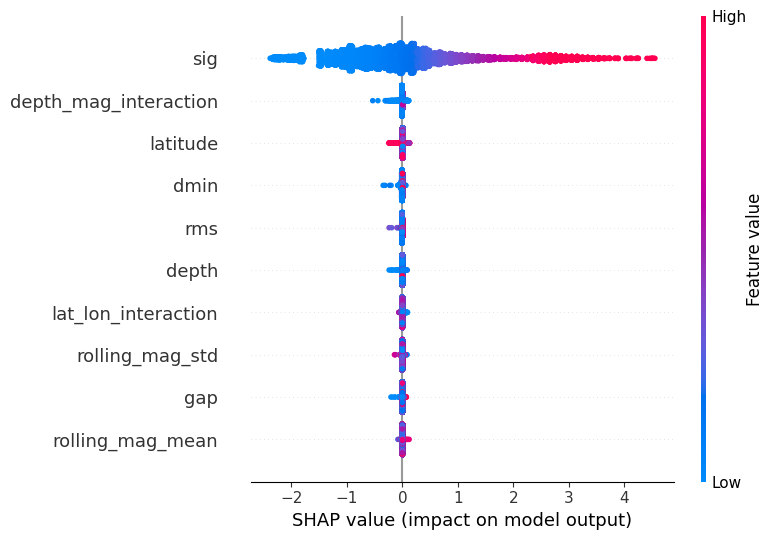

In [46]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer(X)

shap.summary_plot(shap_values, X)

In [47]:
X = X.drop(columns=["sig"])

In [48]:
model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

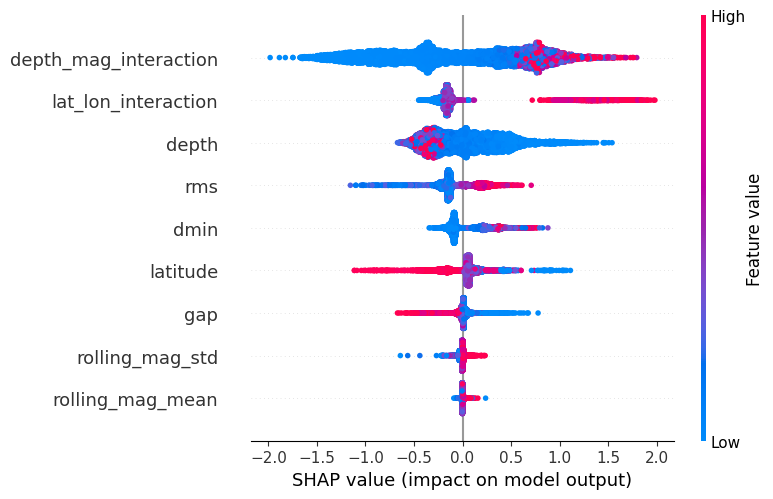

In [49]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X)

shap.summary_plot(shap_values, X)

In [50]:
X = X.drop(columns=["rolling_mag_std", "rolling_mag_mean"], errors="ignore")

In [51]:
model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

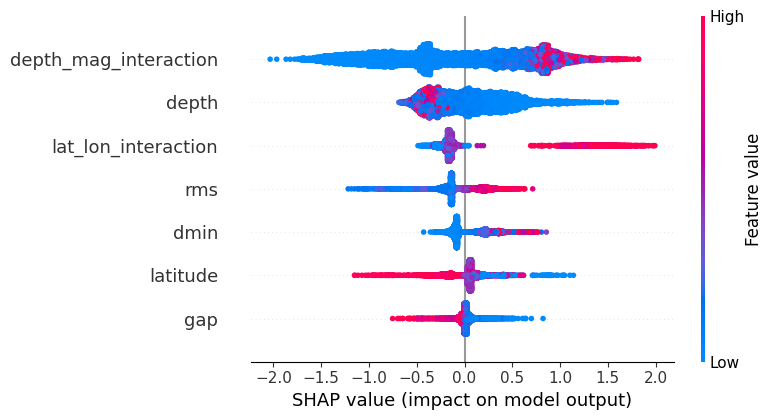

In [52]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X)

shap.summary_plot(shap_values, X)